# 导入包

In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib
import os
import seaborn as sns


os.environ['CUDA_VISIBLE_DEVICES'] = ''  # 禁用CUDA

matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import joblib

# 全局参数设计

In [13]:
try:
    from captum.attr import IntegratedGradients, DeepLift, FeatureAblation

    CAPTUM_AVAILABLE = True
except ImportError:
    CAPTUM_AVAILABLE = False
    print("警告: captum未安装，可解释性功能将受限。安装命令: pip install captum")

# 全局配置
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'WenQuanYi Zen Hei', 'Noto Sans CJK SC']
plt.rcParams['axes.unicode_minus'] = False


# 安全地设置设备
def get_device():
    """安全地获取可用设备"""
    if torch.cuda.is_available():
        try:
            test_tensor = torch.zeros(1).cuda()
            del test_tensor
            return torch.device('cuda')
        except Exception as e:
            print(f"CUDA不可用: {e}")
            return torch.device('cpu')
    return torch.device('cpu')


DEVICE = get_device()
print(f"使用设备: {DEVICE}")

# 全局评估字典
kernal_evals = dict()

使用设备: cpu


#  数据加载与预处理

In [3]:
def load_and_enhanced_preprocess_data():
    try:
        data_train = pd.read_csv("./input/KDDTrain+.txt")
    except FileNotFoundError:
        print("警告：未找到KDDTrain+.txt文件，请确认路径正确")
        raise SystemExit(1)

    columns = (
        ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent',
         'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
         'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login',
         'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
         'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
         'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
         'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'outcome', 'level'])
    data_train.columns = columns

    data_train.loc[data_train['outcome'] == "normal", "outcome"] = 'normal'
    data_train.loc[data_train['outcome'] != 'normal', "outcome"] = 'attack'

    print("执行增强特征工程...")
    data_train['bytes_ratio'] = data_train['src_bytes'] / (data_train['dst_bytes'] + 1)
    data_train['error_rate_sum'] = data_train['serror_rate'] + data_train['rerror_rate']
    data_train['access_intensity'] = data_train['num_access_files'] * data_train['hot']
    data_train['total_bytes'] = data_train['src_bytes'] + data_train['dst_bytes']
    data_train['error_rate_product'] = data_train['serror_rate'] * data_train['rerror_rate']
    data_train['duration_per_byte'] = data_train['duration'] / (data_train['total_bytes'] + 1)

    important_features = ['src_bytes', 'dst_bytes', 'count', 'srv_count', 'dst_host_count']
    for i, feat1 in enumerate(important_features):
        for feat2 in important_features[i + 1:]:
            if feat1 != feat2:
                col_name = f'{feat1}_x_{feat2}'
                data_train[col_name] = data_train[feat1] * data_train[feat2]

    def Scaling(df_num, cols):
        std_scaler = RobustScaler()
        std_scaler_temp = std_scaler.fit_transform(df_num)
        std_df = pd.DataFrame(std_scaler_temp, columns=cols)
        return std_df

    cat_cols = ['is_host_login', 'protocol_type', 'service', 'flag', 'land', 'logged_in', 'is_guest_login', 'level',
                'outcome']

    def enhanced_preprocess(dataframe):
        df_num = dataframe.drop(cat_cols, axis=1)
        num_cols = df_num.columns
        for col in num_cols:
            df_num[col] = pd.to_numeric(df_num[col], errors='coerce')
        df_num = df_num.replace([np.inf, -np.inf], np.nan)
        for col in df_num.columns:
            median_val = df_num[col].median()
            df_num[col] = df_num[col].fillna(median_val)
        for col in df_num.columns:
            Q1 = df_num[col].quantile(0.25)
            Q3 = df_num[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            df_num[col] = np.where(df_num[col] < lower_bound, lower_bound, df_num[col])
            df_num[col] = np.where(df_num[col] > upper_bound, upper_bound, df_num[col])
        scaled_df = Scaling(df_num, num_cols)
        dataframe.drop(labels=num_cols, axis="columns", inplace=True)
        dataframe[num_cols] = scaled_df[num_cols]
        dataframe.loc[dataframe['outcome'] == "normal", "outcome"] = 0
        dataframe.loc[dataframe['outcome'] != 0, "outcome"] = 1
        dataframe = pd.get_dummies(dataframe, columns=['protocol_type', 'service', 'flag'])
        for col in dataframe.columns:
            if dataframe[col].dtype == 'object':
                dataframe[col] = pd.to_numeric(dataframe[col], errors='coerce')
        dataframe = dataframe.fillna(0)
        return dataframe

    scaled_train = enhanced_preprocess(data_train)
    from sklearn.feature_selection import VarianceThreshold
    selector = VarianceThreshold(threshold=0.01)
    x_temp = scaled_train.drop(['outcome', 'level'], axis=1).values.astype(np.float32)
    x_selected = selector.fit_transform(x_temp)
    selected_features = scaled_train.drop(['outcome', 'level'], axis=1).columns[selector.get_support()]
    print(f"原始特征数: {x_temp.shape[1]}, 筛选后特征数: {x_selected.shape[1]}")

    x = x_selected.astype(np.float32)
    y = scaled_train['outcome'].values.astype(np.int64)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

    # 为所有深度学习模型使用数据增强
    x_train_aug, y_train_aug = apply_data_augmentation(x_train, y_train)

    return x_train, x_test, y_train, y_test, x_train_aug, y_train_aug, selected_features.tolist()

In [4]:
def apply_data_augmentation(x_train, y_train):
    from imblearn.combine import SMOTETomek
    print("应用SMOTE+Tomek数据增强...")
    smote_tomek = SMOTETomek(random_state=42)
    x_resampled, y_resampled = smote_tomek.fit_resample(x_train, y_train)
    print(f"数据增强前: 攻击样本={sum(y_train == 1)}, 正常样本={sum(y_train == 0)}")
    print(f"数据增强后: 攻击样本={sum(y_resampled == 1)}, 正常样本={sum(y_resampled == 0)}")
    return x_resampled, y_resampled

# 定义对比模型

In [5]:
class AlexNet1D(nn.Module):
    def __init__(self, input_dim, num_classes=1):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool1d(2, stride=2),
            nn.Conv1d(64, 192, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool1d(2, stride=2),
            nn.Conv1d(192, 384, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv1d(384, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv1d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool1d(2, stride=2),
        )
        self._to_linear = None
        self._get_conv_output(input_dim)
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), nn.Linear(self._to_linear, 4096), nn.ReLU(inplace=True),
            nn.Dropout(0.5), nn.Linear(4096, 4096), nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes)
        )

    def _get_conv_output(self, input_dim):
        with torch.no_grad():
            input = torch.zeros(1, 1, input_dim)
            output = self.feature_extractor(input)
            self._to_linear = output.view(1, -1).size(1)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out


class ResNet1D(nn.Module):
    def __init__(self, input_dim, num_classes=1):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv1d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(64, 3, stride=1)
        self.layer2 = self._make_layer(128, 4, stride=2)
        self.layer3 = self._make_layer(256, 6, stride=2)
        self.layer4 = self._make_layer(512, 3, stride=2)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self._to_linear = None
        self._get_conv_output(input_dim)
        self.fc = nn.Linear(self._to_linear, num_classes)

    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv1d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels),
            )
        layers = []
        layers.append(ResidualBlock1D(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(ResidualBlock1D(out_channels, out_channels))
        return nn.Sequential(*layers)

    def _get_conv_output(self, input_dim):
        with torch.no_grad():
            input = torch.zeros(1, 1, input_dim)
            x = self.conv1(input)
            x = self.bn1(x)
            x = self.relu(x)
            x = self.maxpool(x)
            x = self.layer1(x)
            x = self.layer2(x)
            x = self.layer3(x)
            x = self.layer4(x)
            x = self.avgpool(x)
            self._to_linear = x.view(1, -1).size(1)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class InceptionBlock1D(nn.Module):
    def __init__(self, in_channels, out1, out3_1, out3, out5_1, out5, pool_proj):
        super().__init__()
        self.branch1 = nn.Conv1d(in_channels, out1, kernel_size=1)
        self.branch2 = nn.Sequential(
            nn.Conv1d(in_channels, out3_1, kernel_size=1),
            nn.Conv1d(out3_1, out3, kernel_size=3, padding=1)
        )
        self.branch3 = nn.Sequential(
            nn.Conv1d(in_channels, out5_1, kernel_size=1),
            nn.Conv1d(out5_1, out5, kernel_size=5, padding=2)
        )
        self.branch4 = nn.Sequential(
            nn.MaxPool1d(kernel_size=3, stride=1, padding=1),
            nn.Conv1d(in_channels, pool_proj, kernel_size=1)
        )

    def forward(self, x):
        branch1 = self.branch1(x)
        branch2 = self.branch2(x)
        branch3 = self.branch3(x)
        branch4 = self.branch4(x)
        return torch.cat([branch1, branch2, branch3, branch4], 1)


class GoogleNet1D(nn.Module):
    def __init__(self, input_dim, num_classes=1):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 64, kernel_size=7, stride=2, padding=3)
        self.maxpool1 = nn.MaxPool1d(3, stride=2, padding=1)
        self.conv2 = nn.Conv1d(64, 64, kernel_size=1)
        self.conv3 = nn.Conv1d(64, 192, kernel_size=3, padding=1)
        self.maxpool2 = nn.MaxPool1d(3, stride=2, padding=1)
        self.inception3a = InceptionBlock1D(192, 64, 96, 128, 16, 32, 32)
        self.inception3b = InceptionBlock1D(256, 128, 128, 192, 32, 96, 64)
        self.maxpool3 = nn.MaxPool1d(3, stride=2, padding=1)
        self.inception4a = InceptionBlock1D(480, 192, 96, 208, 16, 48, 64)
        self.inception4b = InceptionBlock1D(512, 160, 112, 224, 24, 64, 64)
        self.inception4c = InceptionBlock1D(512, 128, 128, 256, 24, 64, 64)
        self.inception4d = InceptionBlock1D(512, 112, 144, 288, 32, 64, 64)
        self.inception4e = InceptionBlock1D(528, 256, 160, 320, 32, 128, 128)
        self.maxpool4 = nn.MaxPool1d(3, stride=2, padding=1)
        self.inception5a = InceptionBlock1D(832, 256, 160, 320, 32, 128, 128)
        self.inception5b = InceptionBlock1D(832, 384, 192, 384, 48, 128, 128)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.dropout = nn.Dropout(0.4)
        self._to_linear = None
        self._get_conv_output(input_dim)
        self.fc = nn.Linear(self._to_linear, num_classes)

    def _get_conv_output(self, input_dim):
        with torch.no_grad():
            input = torch.zeros(1, 1, input_dim)
            x = self.conv1(input)
            x = self.maxpool1(x)
            x = self.conv2(x)
            x = self.conv3(x)
            x = self.maxpool2(x)
            x = self.inception3a(x)
            x = self.inception3b(x)
            x = self.maxpool3(x)
            x = self.inception4a(x)
            x = self.inception4b(x)
            x = self.inception4c(x)
            x = self.inception4d(x)
            x = self.inception4e(x)
            x = self.maxpool4(x)
            x = self.inception5a(x)
            x = self.inception5b(x)
            x = self.avgpool(x)
            self._to_linear = x.view(1, -1).size(1)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv1(x)
        x = self.maxpool1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.maxpool2(x)
        x = self.inception3a(x)
        x = self.inception3b(x)
        x = self.maxpool3(x)
        x = self.inception4a(x)
        x = self.inception4b(x)
        x = self.inception4c(x)
        x = self.inception4d(x)
        x = self.inception4e(x)
        x = self.maxpool4(x)
        x = self.inception5a(x)
        x = self.inception5b(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.fc(x)


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        return focal_loss


# 可解释的CKAN实现

In [28]:
class ExplainableConvKANLayer(nn.Module):
    """具有可解释性的ConvKAN层"""

    def __init__(self, in_channels, out_channels, kernel_size=1, grid_size=8, spline_order=3, dropout=0.1,
                 layer_name=None):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.grid_size = grid_size
        self.spline_order = spline_order
        self.layer_name = layer_name or f"ConvKAN_{in_channels}_{out_channels}"

        # 存储激活值用于可视化
        self.activations = None
        self.spline_weights = None

        self.linear = nn.Linear(in_channels, out_channels, bias=False)
        nn.init.kaiming_uniform_(self.linear.weight)

        self.num_basis = grid_size + spline_order
        self.register_buffer('grid', torch.linspace(-1, 1, self.num_basis).unsqueeze(0).repeat(out_channels, 1))
        self.spline_coeff = nn.Parameter(torch.randn(out_channels, self.num_basis) * 0.02)

        self.bn = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, return_activations=False):
        # 线性变换
        linear_out = self.linear(x)

        # 保存线性变换权重用于特征重要性分析
        self.linear_weights = self.linear.weight.data.cpu().numpy()

        # B样条变换
        x_norm = torch.tanh(linear_out)
        grid = self.grid
        x_expanded = x_norm.unsqueeze(-1)

        weights = torch.zeros(x.size(0), self.out_channels, self.num_basis - 1, device=x.device)
        for k in range(self.num_basis - 1):
            left = grid[:, k].view(1, -1, 1)
            right = grid[:, k + 1].view(1, -1, 1)
            mask = (x_expanded >= left) & (x_expanded < right)
            weights[:, :, k] = mask.squeeze(-1).float()

        spline_out = torch.einsum('bck,ck->bc', weights, self.spline_coeff[:, :self.num_basis - 1])

        # 保存样条权重用于分析
        if return_activations:
            self.activations = {
                'linear_out': linear_out.detach().cpu().numpy(),
                'spline_out': spline_out.detach().cpu().numpy(),
                'weights': weights.detach().cpu().numpy(),
                'grid': grid.cpu().numpy()
            }

        out = linear_out + 0.1 * spline_out
        out = self.bn(out)
        out = self.dropout(out)
        return out

    def get_feature_importance(self):
        """获取该层的特征重要性分数"""
        if hasattr(self, 'linear_weights'):
            # 计算每个输入特征对该层输出的平均贡献
            importance = np.abs(self.linear_weights).mean(axis=0)
            return importance
        return None

    def visualize_basis_functions(self, save_path=None):
        """可视化B样条基函数"""
        if not hasattr(self, 'grid'):
            return

        n_channels = min(self.out_channels, 8)
        n_rows = (n_channels + 3) // 4
        fig, axes = plt.subplots(n_rows, min(4, n_channels), figsize=(16, 4 * n_rows))

        if n_rows == 1 and n_channels <= 4:
            axes = axes.flatten() if n_channels > 1 else [axes]
        else:
            axes = axes.flatten() if n_channels > 1 else [axes]

        grid_points = np.linspace(-1, 1, 100)
        for i in range(n_channels):
            ax = axes[i]
            # 计算基函数值
            for k in range(self.num_basis - 1):
                left = self.grid[i, k].cpu().numpy()
                right = self.grid[i, k + 1].cpu().numpy()
                basis = np.where((grid_points >= left) & (grid_points < right), 1.0, 0.0)
                ax.plot(grid_points, basis, label=f'Basis {k}', alpha=0.7, linewidth=1)

            ax.set_title(f'Channel {i} Basis Functions', fontsize=10)
            ax.set_xlabel('x', fontsize=9)
            ax.set_ylabel('Basis Value', fontsize=9)
            if i == 0:
                ax.legend(loc='best', fontsize=7, ncol=2)
            ax.grid(True, alpha=0.3)

        # 隐藏多余的子图
        for i in range(n_channels, len(axes)):
            axes[i].set_visible(False)

        plt.suptitle(f'{self.layer_name} - B-Spline Basis Functions', fontsize=12, fontweight='bold')
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()


# 定义CAKN模型

In [29]:
class CKAN(nn.Module):
    

    def __init__(self, input_dim, feature_names=None, dropout=0.2):
        super().__init__()
        self.input_dim = input_dim
        self.feature_names = feature_names

        self.layers = nn.ModuleList([
            ExplainableConvKANLayer(input_dim, 512, grid_size=12, dropout=dropout, layer_name="layer1_input"),
            ExplainableConvKANLayer(512, 256, grid_size=10, dropout=dropout, layer_name="layer2_hidden"),
            ExplainableConvKANLayer(256, 128, grid_size=8, dropout=dropout, layer_name="layer3_hidden"),
            ExplainableConvKANLayer(128, 64, grid_size=6, dropout=dropout, layer_name="layer4_output")
        ])

        self.multihead_attention = nn.MultiheadAttention(
            embed_dim=64, num_heads=4, dropout=dropout, batch_first=True
        )
        self.residual = nn.Linear(input_dim, 64)
        self.head = nn.Sequential(
            nn.Linear(64, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1)
        )

        # 存储中间激活值用于解释
        self.layer_activations = {}

    def forward(self, x, return_intermediate=False):
        residual = self.residual(x)

        for i, layer in enumerate(self.layers):
            x = layer(x, return_activations=return_intermediate)
            if return_intermediate:
                self.layer_activations[f'layer_{i}'] = layer.activations

        x = x + residual[:, :64]
        x = x.unsqueeze(1)
        x, attention_weights = self.multihead_attention(x, x, x)

        if return_intermediate:
            self.attention_weights = attention_weights.detach().cpu().numpy()

        x = x.squeeze(1)
        output = self.head(x)

        if return_intermediate:
            return output, self.layer_activations, attention_weights
        return output

    def explain_prediction(self, x_sample, target_class=1, method='integrated_gradients'):
        """解释单个预测

        Args:
            x_sample: 输入样本
            target_class: 目标类别 (0=正常, 1=攻击)
            method: 解释方法 ('integrated_gradients', 'deep_lift', 'feature_ablation')

        Returns:
            特征重要性分数
        """
        if not CAPTUM_AVAILABLE:
            print("警告: captum未安装，使用简化版特征重要性计算")
            return self._simple_feature_importance(x_sample)

        self.eval()
        x_tensor = torch.FloatTensor(x_sample).to(DEVICE)
        if x_tensor.dim() == 1:
            x_tensor = x_tensor.unsqueeze(0)

        x_tensor.requires_grad = True

        # 定义前向函数，返回指定类别的输出
        def forward_func(inputs):
            outputs = self(inputs)
            # 对于二分类，target_class=1表示攻击类
            return outputs.squeeze(-1)

        try:
            if method == 'integrated_gradients':
                ig = IntegratedGradients(forward_func)
                # 对于二分类，我们直接使用输出值作为重要性依据
                attributions = ig.attribute(x_tensor, n_steps=50)
                importance = attributions.squeeze().cpu().detach().numpy()

            elif method == 'deep_lift':
                dl = DeepLift(forward_func)
                attributions = dl.attribute(x_tensor)
                importance = attributions.squeeze().cpu().detach().numpy()

            elif method == 'feature_ablation':
                fa = FeatureAblation(forward_func)
                attributions = fa.attribute(x_tensor)
                importance = attributions.squeeze().cpu().detach().numpy()
            else:
                raise ValueError(f"Unknown method: {method}")

        except Exception as e:
            print(f"Captum解释方法失败: {e}，使用简化方法")
            importance = self._simple_feature_importance(x_sample)

        return importance

    def _simple_feature_importance(self, x_sample):
        """简化的特征重要性计算（不依赖captum）"""
        self.eval()
        x_tensor = torch.FloatTensor(x_sample).to(DEVICE)
        if x_tensor.dim() == 1:
            x_tensor = x_tensor.unsqueeze(0)

        x_tensor.requires_grad = True

        # 计算输出相对于输入的梯度
        output = self(x_tensor)
        output.backward()

        # 使用梯度作为特征重要性
        importance = x_tensor.grad.squeeze().cpu().detach().numpy()
        importance = np.abs(importance)  # 使用绝对值

        return importance

    def get_layer_wise_importance(self, x_batch):
        """获取每层特征重要性"""
        self.eval()
        layer_importances = {}

        def hook_fn(module, input, output):
            if hasattr(module, 'linear_weights'):
                layer_importances[module.layer_name] = module.get_feature_importance()

        # 注册hooks
        hooks = []
        for layer in self.layers:
            hooks.append(layer.register_forward_hook(hook_fn))

        with torch.no_grad():
            x_tensor = torch.FloatTensor(x_batch).to(DEVICE)
            _ = self(x_tensor)

        for hook in hooks:
            hook.remove()

        return layer_importances

    def visualize_feature_importance(self, feature_importance, top_k=20, save_path=None):
        """可视化特征重要性"""
        if self.feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(len(feature_importance))]
        else:
            feature_names = self.feature_names

        # 确保特征名称数量匹配
        if len(feature_names) != len(feature_importance):
            feature_names = [f'Feature_{i}' for i in range(len(feature_importance))]

        # 获取top-k特征
        top_indices = np.argsort(np.abs(feature_importance))[-top_k:][::-1]
        top_features = [feature_names[i] for i in top_indices]
        top_scores = feature_importance[top_indices]

        fig, ax = plt.subplots(figsize=(12, max(6, top_k * 0.3)))
        colors = ['red' if x > 0 else 'blue' for x in top_scores]
        bars = ax.barh(range(len(top_features)), top_scores, color=colors, alpha=0.8)

        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features, fontsize=10)
        ax.set_xlabel('Importance Score', fontsize=12)
        ax.set_title(f'Top-{top_k} Feature Importance for Attack Detection', fontsize=14, fontweight='bold')
        ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
        ax.grid(True, alpha=0.3, axis='x')

        # 添加图例
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor='red', alpha=0.8, label='Positive Contribution (Attack)'),
                           Patch(facecolor='blue', alpha=0.8, label='Negative Contribution (Normal)')]
        ax.legend(handles=legend_elements, loc='lower right')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()

        return top_features, top_scores

    def visualize_attention_weights(self, save_path=None):
        """可视化注意力权重"""
        if not hasattr(self, 'attention_weights'):
            print("No attention weights available. Run forward with return_intermediate=True first.")
            return

        attention = self.attention_weights[0]  # [batch, heads, seq_len, seq_len]
        n_heads = min(attention.shape[0], 4)

        fig, axes = plt.subplots(1, n_heads, figsize=(4 * n_heads, 4))
        if n_heads == 1:
            axes = [axes]

        for i in range(n_heads):
            im = axes[i].imshow(attention[i], cmap='viridis', aspect='auto')
            axes[i].set_title(f'Attention Head {i + 1}')
            axes[i].set_xlabel('Key Position')
            axes[i].set_ylabel('Query Position')
            plt.colorbar(im, ax=axes[i])

        plt.suptitle('Multi-Head Attention Weights Visualization', fontsize=14, fontweight='bold')
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()

    def visualize_spline_functions(self, save_dir=None):
        """可视化所有层的样条函数"""
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)

        for i, layer in enumerate(self.layers):
            save_path = None
            if save_dir:
                save_path = os.path.join(save_dir, f'spline_basis_layer_{i}_{layer.layer_name}.png')
            layer.visualize_basis_functions(save_path)


#  模型参数量统计模块 

In [30]:
def count_model_parameters(model, model_name="Model"):
    """统计模型的参数量"""
    if hasattr(model, 'parameters'):
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        non_trainable_params = total_params - trainable_params

        print(f"\n{model_name} 参数量统计:")
        print(f"  总参数量: {total_params:,}")
        print(f"  可训练参数: {trainable_params:,}")
        print(f"  不可训练参数: {non_trainable_params:,}")

        return {
            'model_name': model_name,
            'total_params': total_params,
            'trainable_params': trainable_params,
            'non_trainable_params': non_trainable_params,
            'type': 'PyTorch'
        }
    return None


def compare_all_models_parameters(models_dict):
    """对比所有模型的参数量"""
    print("\n" + "=" * 80)
    print(" 模型参数量对比分析")
    print("=" * 80)

    param_comparison = []
    for name, model in models_dict.items():
        if model is not None:
            param_info = count_model_parameters(model, name)
            if param_info:
                param_comparison.append(param_info)

    if param_comparison:
        df_params = pd.DataFrame(param_comparison)
        df_params = df_params.sort_values('total_params', ascending=False)

        print("\n参数量排名 (从大到小):")
        print("-" * 70)
        for _, row in df_params.iterrows():
            params_m = row['total_params'] / 1e6 if row['total_params'] > 0 else 0
            print(
                f"  {row['model_name']:25s} | {row['total_params']:>12,} 参数 | {params_m:>8.2f}M | {row['type']:10s}")

        # 可视化
        plt.figure(figsize=(12, 6))
        plot_data = df_params[df_params['total_params'] > 0].copy()
        if not plot_data.empty:
            colors = plt.cm.viridis(np.linspace(0, 1, len(plot_data)))
            bars = plt.barh(range(len(plot_data)), plot_data['total_params'].values, color=colors)
            plt.yticks(range(len(plot_data)), plot_data['model_name'].values)
            plt.xlabel('parameters', fontsize=12)
            plt.title('model parameter compare', fontsize=14)
            plt.gca().invert_yaxis()

            for i, (bar, val) in enumerate(zip(bars, plot_data['total_params'].values)):
                if val > 1e6:
                    label = f'{val / 1e6:.2f}M'
                elif val > 1e3:
                    label = f'{val / 1e3:.2f}K'
                else:
                    label = f'{val}'
                plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f' {label}', va='center', fontsize=10)

            plt.tight_layout()
            plt.savefig('model_parameters_comparison.png', dpi=150, bbox_inches='tight')
            plt.close()

    return df_params


# 定义训练函数

In [31]:
def train_deep_model(model, model_name, x_train, y_train, x_test, y_test, input_dim, epochs=20):
    """通用深度学习模型训练函数"""
    model = model.to(DEVICE)
    criterion = FocalLoss(alpha=0.75, gamma=2.0)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=10, factor=0.5)

    train_dataset = TensorDataset(
        torch.FloatTensor(x_train),
        torch.FloatTensor(y_train).unsqueeze(1)
    )
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=0)

    best_acc = 0
    best_state = None

    print(f"\n开始训练{model_name}...")
    total_params = sum(p.numel() for p in model.parameters())
    print(f"模型参数量: {total_params:,}")

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for bx, by in train_loader:
            bx = bx.to(DEVICE)
            by = by.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(bx)
            loss = criterion(outputs, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        if (epoch + 1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                x_test_tensor = torch.FloatTensor(x_test).to(DEVICE)
                probs = torch.sigmoid(model(x_test_tensor)).cpu().numpy().squeeze()
                pred = (probs > 0.5).astype(int)
                acc = (pred == y_test).mean()
                print(f"Epoch {epoch + 1}/{epochs}, Loss: {total_loss / len(train_loader):.4f}, Val Acc: {acc:.4f}")

                if acc > best_acc:
                    best_acc = acc
                    best_state = model.state_dict().copy()

        scheduler.step(best_acc)

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"{model_name}最佳准确率: {best_acc:.4f}")
    return model


def train_ckan_advanced(x_train, y_train, x_test, y_test, input_dim, feature_names=None):
    """高级训练策略 - 使用可解释CKAN"""
    model = CKAN(input_dim, feature_names=feature_names, dropout=0.2).to(DEVICE)

    def warmup_lambda(epoch):
        if epoch < 10:
            return (epoch + 1) / 10
        return 0.95 ** ((epoch - 10) // 5)

    criterion = FocalLoss(alpha=0.75, gamma=2.0)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_lambda)

    train_dataset = TensorDataset(
        torch.FloatTensor(x_train),
        torch.FloatTensor(y_train).unsqueeze(1)
    )
    train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=0)

    best_acc = 0
    best_state = None
    patience = 20
    patience_counter = 0

    print("\n" + "=" * 60)
    print("开始训练可解释CKAN...")
    print("=" * 60)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"模型参数量: {total_params:,}")

    for epoch in range(200):
        model.train()
        total_loss = 0

        for bx, by in train_loader:
            bx = bx.to(DEVICE)
            by = by.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(bx)
            loss = criterion(outputs, by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)

        if (epoch + 1) % 10 == 0:
            model.eval()
            with torch.no_grad():
                x_test_tensor = torch.FloatTensor(x_test).to(DEVICE)
                probs = torch.sigmoid(model(x_test_tensor)).cpu().numpy().squeeze()
                pred = (probs > 0.5).astype(int)
                acc = (pred == y_test).mean()
                print(f"Epoch {epoch + 1}/200, Loss: {avg_loss:.4f}, Val Acc: {acc:.4f}")

                if acc > best_acc:
                    best_acc = acc
                    best_state = model.state_dict().copy()
                    patience_counter = 0
                else:
                    patience_counter += 1

                if patience_counter >= patience:
                    print(f"早停触发！最佳准确率: {best_acc:.4f}")
                    break

        scheduler.step()

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"\n CKAN最佳准确率: {best_acc:.4f}")
    return model, best_acc

# 定义评估函数

In [33]:
def enhanced_evaluate_classification(model, name, X_train, X_test, y_train, y_test):
    """评估分类模型性能"""
    if hasattr(model, 'predict'):
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        if hasattr(model, 'predict_proba'):
            y_test_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_test_proba = None
    else:
        model.eval()
        with torch.no_grad():
            X_train_tensor = torch.FloatTensor(X_train).to(DEVICE)
            X_test_tensor = torch.FloatTensor(X_test).to(DEVICE)
            train_outputs = model(X_train_tensor)
            test_outputs = model(X_test_tensor)
            y_train_pred = (torch.sigmoid(train_outputs) > 0.5).float().cpu().numpy().squeeze()
            y_test_pred = (torch.sigmoid(test_outputs) > 0.5).float().cpu().numpy().squeeze()
            y_test_proba = torch.sigmoid(test_outputs).cpu().numpy().squeeze()

    train_accuracy = metrics.accuracy_score(y_train, y_train_pred)
    test_accuracy = metrics.accuracy_score(y_test, y_test_pred)
    train_precision = metrics.precision_score(y_train, y_train_pred, zero_division=0)
    test_precision = metrics.precision_score(y_test, y_test_pred, zero_division=0)
    train_recall = metrics.recall_score(y_train, y_train_pred, zero_division=0)
    test_recall = metrics.recall_score(y_test, y_test_pred, zero_division=0)
    train_f1 = metrics.f1_score(y_train, y_train_pred, zero_division=0)
    test_f1 = metrics.f1_score(y_test, y_test_pred, zero_division=0)

    test_auc = 0
    if y_test_proba is not None:
        try:
            test_auc = metrics.roc_auc_score(y_test, y_test_proba)
        except:
            test_auc = 0.5

    param_info = count_model_parameters(model, name)
    total_params = param_info['total_params'] if param_info else 0

    kernal_evals[name] = {
        'model': model,
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'test_auc': test_auc,
        'total_params': total_params
    }

    print("=" * 70)
    print(f" 模型: {name}")
    print("=" * 70)
    if total_params > 1e6:
        print(f"参数量: {total_params / 1e6:.2f}M")
    elif total_params > 1e3:
        print(f"参数量: {total_params / 1e3:.2f}K")
    else:
        print(f"参数量: {total_params}")
    print(f"测试集 - 准确率: {test_accuracy * 100:.2f}% | F1: {test_f1 * 100:.2f}% | AUC: {test_auc:.4f}")

# 可解释性分析函数

In [34]:
def perform_explainability_analysis(model, x_test, y_test, feature_names, save_dir='explainability_results'):
    """执行完整的可解释性分析"""
    os.makedirs(save_dir, exist_ok=True)

    print("\n" + "=" * 80)
    print("  开始CKAN模型可解释性分析")
    print("=" * 80)

    # 1. 全局特征重要性分析
    print("\n1. 计算全局特征重要性...")
    # 选取一些样本计算平均特征重要性
    n_samples = min(50, len(x_test))
    sample_indices = np.random.choice(len(x_test), n_samples, replace=False)

    all_importances = []
    for idx in sample_indices[:20]:  # 使用20个样本减少计算时间
        try:
            importance = model.explain_prediction(x_test[idx], target_class=1, method='integrated_gradients')
            all_importances.append(importance)
        except Exception as e:
            print(f"  样本{idx}解释失败: {e}")
            continue

    if all_importances:
        global_importance = np.mean(all_importances, axis=0)

        # 可视化全局特征重要性
        top_features, top_scores = model.visualize_feature_importance(
            global_importance,
            top_k=20,
            save_path=os.path.join(save_dir, 'global_feature_importance.png')
        )
    else:
        print("  警告: 无法计算全局特征重要性")
        global_importance = np.zeros(x_test.shape[1])
        top_features, top_scores = [], []

    # 2. 对比正常和攻击样本的特征重要性
    print("\n2. 对比正常样本和攻击样本的特征贡献...")
    normal_indices = np.where(y_test == 0)[0][:10]
    attack_indices = np.where(y_test == 1)[0][:10]

    normal_importances = []
    attack_importances = []

    for idx in normal_indices:
        try:
            imp = model.explain_prediction(x_test[idx], target_class=0, method='integrated_gradients')
            normal_importances.append(imp)
        except Exception as e:
            print(f"  正常样本{idx}解释失败: {e}")

    for idx in attack_indices:
        try:
            imp = model.explain_prediction(x_test[idx], target_class=1, method='integrated_gradients')
            attack_importances.append(imp)
        except Exception as e:
            print(f"  攻击样本{idx}解释失败: {e}")

    if normal_importances and attack_importances:
        avg_normal_imp = np.mean(normal_importances, axis=0)
        avg_attack_imp = np.mean(attack_importances, axis=0)

        # 可视化对比
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        for idx, (imp, title, ax) in enumerate(zip(
                [avg_normal_imp, avg_attack_imp],
                ['Normal Traffic Feature Importance', 'Attack Traffic Feature Importance'],
                axes
        )):
            top_k = min(15, len(imp))
            top_indices = np.argsort(np.abs(imp))[-top_k:][::-1]
            top_feat_names = [feature_names[i] if i < len(feature_names) else f'F{i}' for i in top_indices]
            top_scores = imp[top_indices]

            colors = ['green' if x > 0 else 'red' for x in top_scores]
            ax.barh(range(len(top_feat_names)), top_scores, color=colors, alpha=0.8)
            ax.set_yticks(range(len(top_feat_names)))
            ax.set_yticklabels(top_feat_names, fontsize=9)
            ax.set_xlabel('Importance Score')
            ax.set_title(title)
            ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
            ax.grid(True, alpha=0.3, axis='x')

        plt.tight_layout()
        plt.savefig(os.path.join(save_dir, 'normal_vs_attack_importance.png'), dpi=150, bbox_inches='tight')
        plt.close()

    # 3. 分析特定攻击样本的决策过程
    print("\n3. 分析典型攻击样本的决策过程...")
    if len(attack_indices) > 0:
        attack_sample_idx = attack_indices[0]

        # 获取详细解释
        try:
            with torch.no_grad():
                x_sample = torch.FloatTensor(x_test[attack_sample_idx:attack_sample_idx + 1]).to(DEVICE)
                output, layer_acts, attn_weights = model(x_sample, return_intermediate=True)
                prediction = torch.sigmoid(output).item()

            print(f"\n样本分析:")
            print(f"  真实标签: {'攻击' if y_test[attack_sample_idx] == 1 else '正常'}")
            print(f"  预测概率: {prediction:.4f}")
            print(f"  预测结果: {'攻击' if prediction > 0.5 else '正常'}")

            # 可视化注意力权重
            model.visualize_attention_weights(save_path=os.path.join(save_dir, 'attention_weights.png'))
        except Exception as e:
            print(f"  样本分析失败: {e}")

    # 4. 可视化样条基函数
    print("\n4. 可视化B样条基函数...")
    try:
        model.visualize_spline_functions(save_dir=os.path.join(save_dir, 'spline_basis'))
        print("  样条基函数可视化完成")
    except Exception as e:
        print(f"  样条基函数可视化失败: {e}")

    # 5. 生成可解释性报告
    if all_importances and normal_importances and attack_importances:
        generate_explainability_report(
            model, global_importance, feature_names,
            normal_importances, attack_importances,
            save_dir
        )

    return {
        'global_importance': global_importance,
        'normal_importance': avg_normal_imp if normal_importances else None,
        'attack_importance': avg_attack_imp if attack_importances else None,
        'top_features': top_features,
        'top_scores': top_scores
    }


def generate_explainability_report(model, global_importance, feature_names,
                                   normal_importances, attack_importances, save_dir):
    """生成可解释性分析报告"""
    report_path = os.path.join(save_dir, 'explainability_report.txt')

    avg_normal = np.mean(normal_importances, axis=0)
    avg_attack = np.mean(attack_importances, axis=0)

    with open(report_path, 'w', encoding='utf-8') as f:
        f.write("=" * 80 + "\n")
        f.write("CKAN模型可解释性分析报告\n")
        f.write("=" * 80 + "\n\n")

        # 模型架构信息
        f.write("1. 模型架构\n")
        f.write("-" * 40 + "\n")
        f.write(f"   输入维度: {model.input_dim}\n")
        f.write(f"   隐藏层: 512 -> 256 -> 128 -> 64\n")
        f.write(f"   注意力头数: 4\n")
        f.write(f"   总参数量: {sum(p.numel() for p in model.parameters()):,}\n\n")

        # Top-10最重要特征
        f.write("2. 全局最重要的10个特征 (攻击检测)\n")
        f.write("-" * 40 + "\n")
        top_indices = np.argsort(np.abs(global_importance))[-10:][::-1]
        for i, idx in enumerate(top_indices, 1):
            feat_name = feature_names[idx] if idx < len(feature_names) else f'Feature_{idx}'
            f.write(f"   {i:2d}. {feat_name:30s} | 重要性分数: {global_importance[idx]:+.4f}\n")

        # 正常vs攻击特征对比
        f.write("\n3. 正常流量 vs 攻击流量特征贡献对比\n")
        f.write("-" * 40 + "\n")
        top_diff_indices = np.argsort(np.abs(avg_attack - avg_normal))[-10:][::-1]
        for i, idx in enumerate(top_diff_indices, 1):
            feat_name = feature_names[idx] if idx < len(feature_names) else f'Feature_{idx}'
            f.write(
                f"   {i:2d}. {feat_name:30s} | 正常: {avg_normal[idx]:+.4f} | 攻击: {avg_attack[idx]:+.4f} | 差异: {avg_attack[idx] - avg_normal[idx]:+.4f}\n")

        f.write("\n" + "=" * 80 + "\n")
        f.write("解释说明:\n")
        f.write("  - 正重要性分数: 该特征促进攻击检测\n")
        f.write("  - 负重要性分数: 该特征抑制攻击检测（倾向于正常）\n")
        f.write("  - 差异越大表示该特征在区分正常和攻击流量时越重要\n")
        f.write("=" * 80 + "\n")

    print(f"\n  可解释性报告已保存到: {report_path}")

In [14]:
if not CAPTUM_AVAILABLE:
    print("\n   注意: captum未安装，将使用简化版特征重要性计算")
    print("   如需完整可解释性功能，请安装: pip install captum\n")

# 加载数据

In [35]:
x_train, x_test, y_train, y_test, x_train_aug, y_train_aug, feature_names = load_and_enhanced_preprocess_data()
print(f"\n数据统计:")
print(f"训练集: {x_train.shape[0]}个样本, {x_train.shape[1]}个特征")
print(f"测试集: {x_test.shape[0]}个样本")

执行增强特征工程...
原始特征数: 138, 筛选后特征数: 49
应用SMOTE+Tomek数据增强...
数据增强前: 攻击样本=46904, 正常样本=53873
数据增强后: 攻击样本=53831, 正常样本=53831

数据统计:
训练集: 100777个样本, 49个特征
测试集: 25195个样本


# 训练AlexNet模型

In [24]:
print("训练AlexNet模型...")
alexnet_model = train_deep_model(
    AlexNet1D(x_train.shape[1]), "AlexNet",
     x_train_aug, y_train_aug, x_test, y_test, x_train.shape[1], epochs=50
  )
enhanced_evaluate_classification(alexnet_model, "AlexNet", x_train, x_test, y_train, y_test)

训练AlexNet模型...

开始训练AlexNet...
模型参数量: 23,831,873
Epoch 10/50, Loss: 0.0019, Val Acc: 0.9962
Epoch 20/50, Loss: 0.0015, Val Acc: 0.9957
Epoch 30/50, Loss: 0.0006, Val Acc: 0.9985
Epoch 40/50, Loss: 0.0005, Val Acc: 0.9984
Epoch 50/50, Loss: 0.0002, Val Acc: 0.9988
AlexNet最佳准确率: 0.9988

📊 AlexNet 参数量统计:
  总参数量: 23,831,873
  可训练参数: 23,831,873
  不可训练参数: 0
📊 模型: AlexNet
参数量: 23.83M
测试集 - 准确率: 99.88% | F1: 99.87% | AUC: 0.9999


# 训练ResNet50模型

In [25]:
resnet_model = train_deep_model(
    ResNet1D(x_train.shape[1]), "ResNet50",
    x_train_aug, y_train_aug, x_test, y_test, x_train.shape[1], epochs=50
    )
enhanced_evaluate_classification(resnet_model, "ResNet50", x_train, x_test, y_train, y_test)


开始训练ResNet50...
模型参数量: 7,218,753
Epoch 10/50, Loss: 0.0021, Val Acc: 0.9965
Epoch 20/50, Loss: 0.0011, Val Acc: 0.9968
Epoch 30/50, Loss: 0.0009, Val Acc: 0.9976
Epoch 40/50, Loss: 0.0009, Val Acc: 0.9982
Epoch 50/50, Loss: 0.0005, Val Acc: 0.9984
ResNet50最佳准确率: 0.9984

📊 ResNet50 参数量统计:
  总参数量: 7,218,753
  可训练参数: 7,218,753
  不可训练参数: 0
📊 模型: ResNet50
参数量: 7.22M
测试集 - 准确率: 99.84% | F1: 99.83% | AUC: 0.9999


# 训练GoogleNet模型

In [26]:
googlenet_model = train_deep_model(
    GoogleNet1D(x_train.shape[1]), "GoogleNet",
     x_train_aug, y_train_aug, x_test, y_test, x_train.shape[1], epochs=50
    )
enhanced_evaluate_classification(googlenet_model, "GoogleNet", x_train, x_test, y_train, y_test)


开始训练GoogleNet...
模型参数量: 3,422,001
Epoch 10/50, Loss: 0.0034, Val Acc: 0.9957
Epoch 20/50, Loss: 0.0013, Val Acc: 0.9976
Epoch 30/50, Loss: 28138.4628, Val Acc: 0.9974
Epoch 40/50, Loss: 0.0009, Val Acc: 0.9973
Epoch 50/50, Loss: 0.0003, Val Acc: 0.9977
GoogleNet最佳准确率: 0.9977

📊 GoogleNet 参数量统计:
  总参数量: 3,422,001
  可训练参数: 3,422,001
  不可训练参数: 0
📊 模型: GoogleNet
参数量: 3.42M
测试集 - 准确率: 99.77% | F1: 99.75% | AUC: 0.9999


# 训练可解释增强版CKAN模型

In [36]:
kan_model, kan_best_acc = train_ckan_advanced(
    x_train_aug, y_train_aug, x_test, y_test,
    x_train.shape[1], feature_names=feature_names
    )
enhanced_evaluate_classification(kan_model, "CKAN", x_train, x_test, y_train, y_test)


开始训练可解释CKAN...
模型参数量: 250,945
Epoch 10/200, Loss: 0.0062, Val Acc: 0.9918
Epoch 20/200, Loss: 0.0049, Val Acc: 0.9933
Epoch 30/200, Loss: 0.0042, Val Acc: 0.9945
Epoch 40/200, Loss: 0.0037, Val Acc: 0.9940
Epoch 50/200, Loss: 0.0035, Val Acc: 0.9957
Epoch 60/200, Loss: 0.0032, Val Acc: 0.9958
Epoch 70/200, Loss: 0.0030, Val Acc: 0.9961
Epoch 80/200, Loss: 0.0028, Val Acc: 0.9966
Epoch 90/200, Loss: 0.0026, Val Acc: 0.9968
Epoch 100/200, Loss: 0.0026, Val Acc: 0.9965
Epoch 110/200, Loss: 0.0022, Val Acc: 0.9968
Epoch 120/200, Loss: 0.0024, Val Acc: 0.9966
Epoch 130/200, Loss: 0.0023, Val Acc: 0.9970
Epoch 140/200, Loss: 0.0020, Val Acc: 0.9973
Epoch 150/200, Loss: 0.0020, Val Acc: 0.9971
Epoch 160/200, Loss: 0.0020, Val Acc: 0.9969
Epoch 170/200, Loss: 0.0020, Val Acc: 0.9970
Epoch 180/200, Loss: 0.0018, Val Acc: 0.9973
Epoch 190/200, Loss: 0.0019, Val Acc: 0.9973
Epoch 200/200, Loss: 0.0018, Val Acc: 0.9973

🎉 CKAN最佳准确率: 0.9973

📊 CKAN 参数量统计:
  总参数量: 250,945
  可训练参数: 250,945
  不可训练参数:

# 对CKAN模型进行可解释性分析

In [37]:
explainability_results = perform_explainability_analysis(
    kan_model, x_test, y_test, feature_names, save_dir='explainability_results'
    )


🔍 开始CKAN模型可解释性分析

1. 计算全局特征重要性...

2. 对比正常样本和攻击样本的特征贡献...

3. 分析典型攻击样本的决策过程...

样本分析:
  真实标签: 攻击
  预测概率: 1.0000
  预测结果: 攻击
  样本分析失败: Invalid shape (1,) for image data

4. 可视化B样条基函数...
  样条基函数可视化完成

📄 可解释性报告已保存到: explainability_results/explainability_report.txt


# CKAN模型可解释性分析

1. 模型架构
----------------------------------------
   输入维度: 49
   隐藏层: 512 -> 256 -> 128 -> 64
   注意力头数: 4
   总参数量: 250,945

2. 全局最重要的10个特征 (攻击检测)
----------------------------------------
    1. same_srv_rate                  | 重要性分数: +3.1715
    2. error_rate_sum                 | 重要性分数: +2.2344
    3. src_bytes_x_dst_bytes          | 重要性分数: +2.0211
    4. dst_host_count                 | 重要性分数: -1.8232
    5. serror_rate                    | 重要性分数: -1.7179
    6. count                          | 重要性分数: +1.6111
    7. dst_host_same_srv_rate         | 重要性分数: +1.5137
    8. flag_S0                        | 重要性分数: +1.4325
    9. src_bytes                      | 重要性分数: -1.3956
   10. src_bytes_x_dst_host_count     | 重要性分数: -1.1015

3. 正常流量 vs 攻击流量特征贡献对比
----------------------------------------
    1. same_srv_rate                  | 正常: +0.0000 | 攻击: +5.2220 | 差异: +5.2220
    2. src_bytes                      | 正常: -3.5738 | 攻击: +0.8817 | 差异: +4.4555
    3. dst_host_count                 | 正常: -4.6709 | 攻击: -0.6695 | 差异: +4.0014
    4. src_bytes_x_dst_bytes          | 正常: +3.7515 | 攻击: +0.0000 | 差异: -3.7515
    5. dst_host_same_srv_rate         | 正常: -1.0056 | 攻击: +2.7141 | 差异: +3.7198
    6. error_rate_sum                 | 正常: +0.0220 | 攻击: +3.1866 | 差异: +3.1646
    7. flag_S0                        | 正常: +0.0000 | 攻击: +3.0171 | 差异: +3.0171
    8. serror_rate                    | 正常: -0.0361 | 攻击: -2.9479 | 差异: -2.9119
    9. count                          | 正常: -0.0228 | 攻击: +2.5143 | 差异: +2.5371
    10. service_http                   | 正常: -2.2174 | 攻击: +0.0000 | 差异: +2.2174

# 显示前20最重要特征

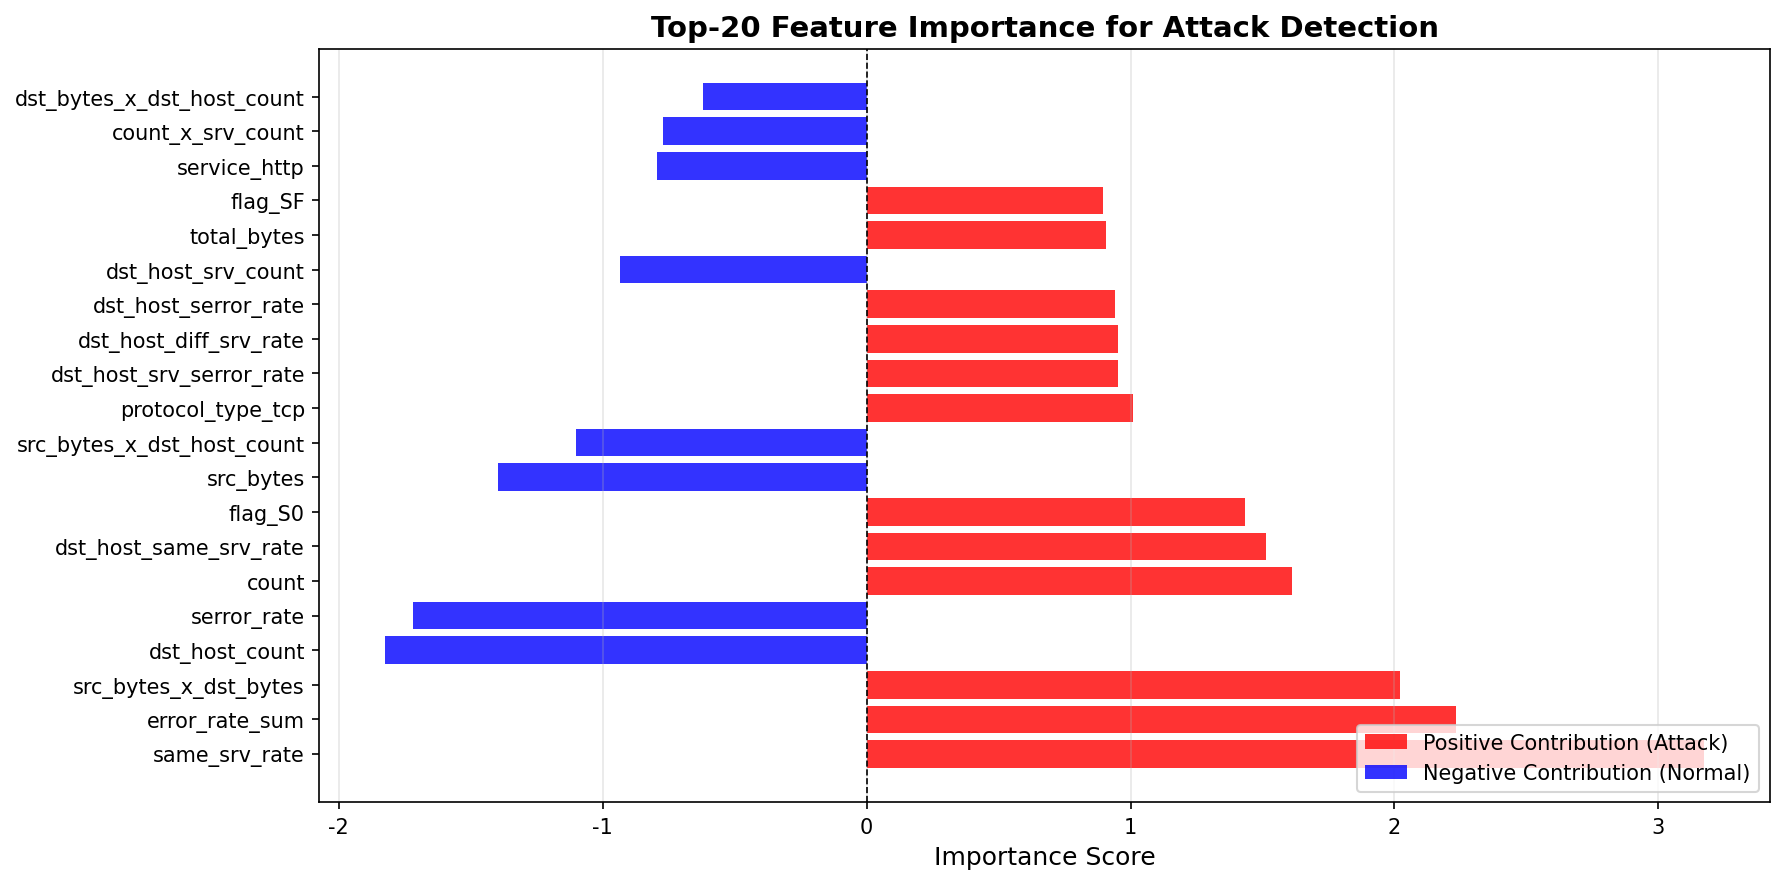

In [42]:
from IPython.display import Image, display

# 传入图片路径
img = Image("explainability_results/global_feature_importance.png")
display(img)

# 正常流量vs攻击流量特征贡献对比

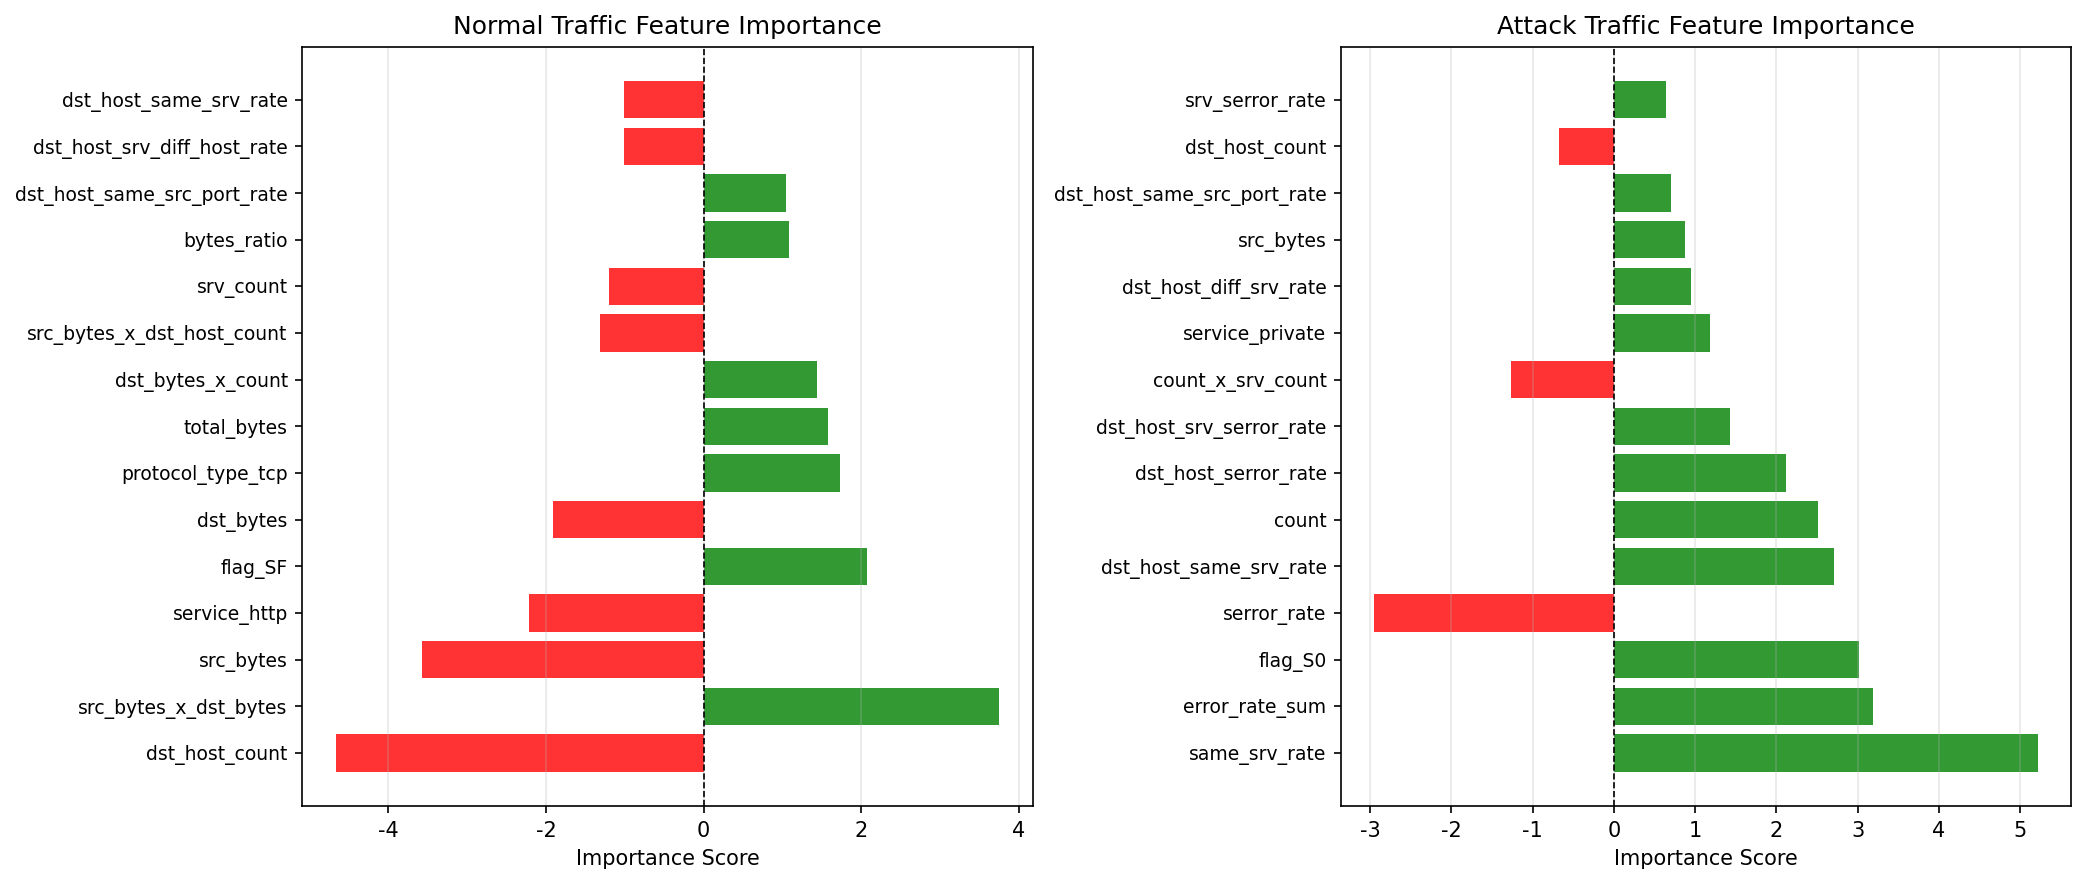

In [43]:

# 传入图片路径
img = Image("explainability_results/normal_vs_attack_importance.png")
display(img)

# 可视化B样条基函数

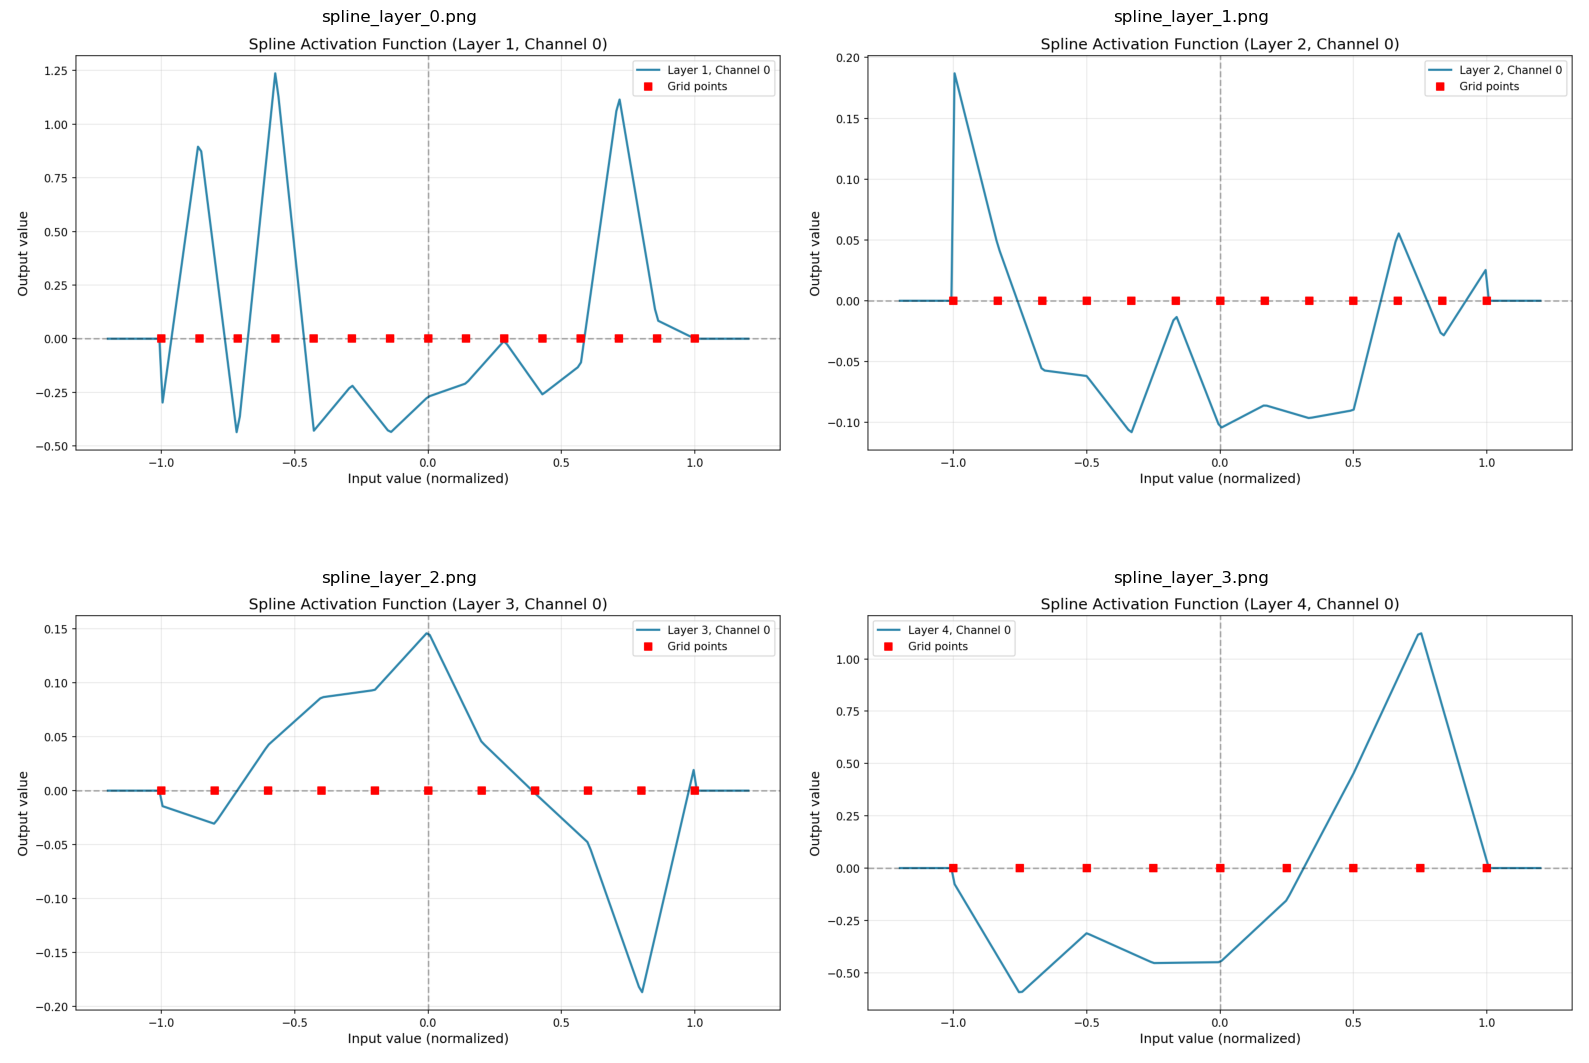

In [49]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# 图片路径列表
paths = [
    "spline_layer_0.png",
    "spline_layer_1.png",
    "spline_layer_2.png",
    "spline_layer_3.png"
]

plt.figure(figsize=(16, 12))
for idx, path in enumerate(paths):
    img = mpimg.imread(path)
    # 2行2列，位置1~4
    plt.subplot(2, 2, idx + 1)
    plt.imshow(img)
    plt.axis("off")  # 隐藏坐标轴
    plt.title(path)
plt.tight_layout()
plt.show()

# 模型参数量综合对比

In [38]:
all_models = {
        "AlexNet": alexnet_model,
        "ResNet50": resnet_model,
        "GoogleNet": googlenet_model,
        "CKAN": kan_model,
    }
compare_all_models_parameters(all_models)


📊 模型参数量对比分析

📊 AlexNet 参数量统计:
  总参数量: 23,831,873
  可训练参数: 23,831,873
  不可训练参数: 0

📊 ResNet50 参数量统计:
  总参数量: 7,218,753
  可训练参数: 7,218,753
  不可训练参数: 0

📊 GoogleNet 参数量统计:
  总参数量: 3,422,001
  可训练参数: 3,422,001
  不可训练参数: 0

📊 CKAN 参数量统计:
  总参数量: 250,945
  可训练参数: 250,945
  不可训练参数: 0

📈 参数量排名 (从大到小):
----------------------------------------------------------------------
  AlexNet                   |   23,831,873 参数 |    23.83M | PyTorch   
  ResNet50                  |    7,218,753 参数 |     7.22M | PyTorch   
  GoogleNet                 |    3,422,001 参数 |     3.42M | PyTorch   
  CKAN                      |      250,945 参数 |     0.25M | PyTorch   


,model_name,total_params,trainable_params,non_trainable_params,type
0,AlexNet,23831873,23831873,0,PyTorch
1,ResNet50,7218753,7218753,0,PyTorch
2,GoogleNet,3422001,3422001,0,PyTorch
3,CKAN,250945,250945,0,PyTorch


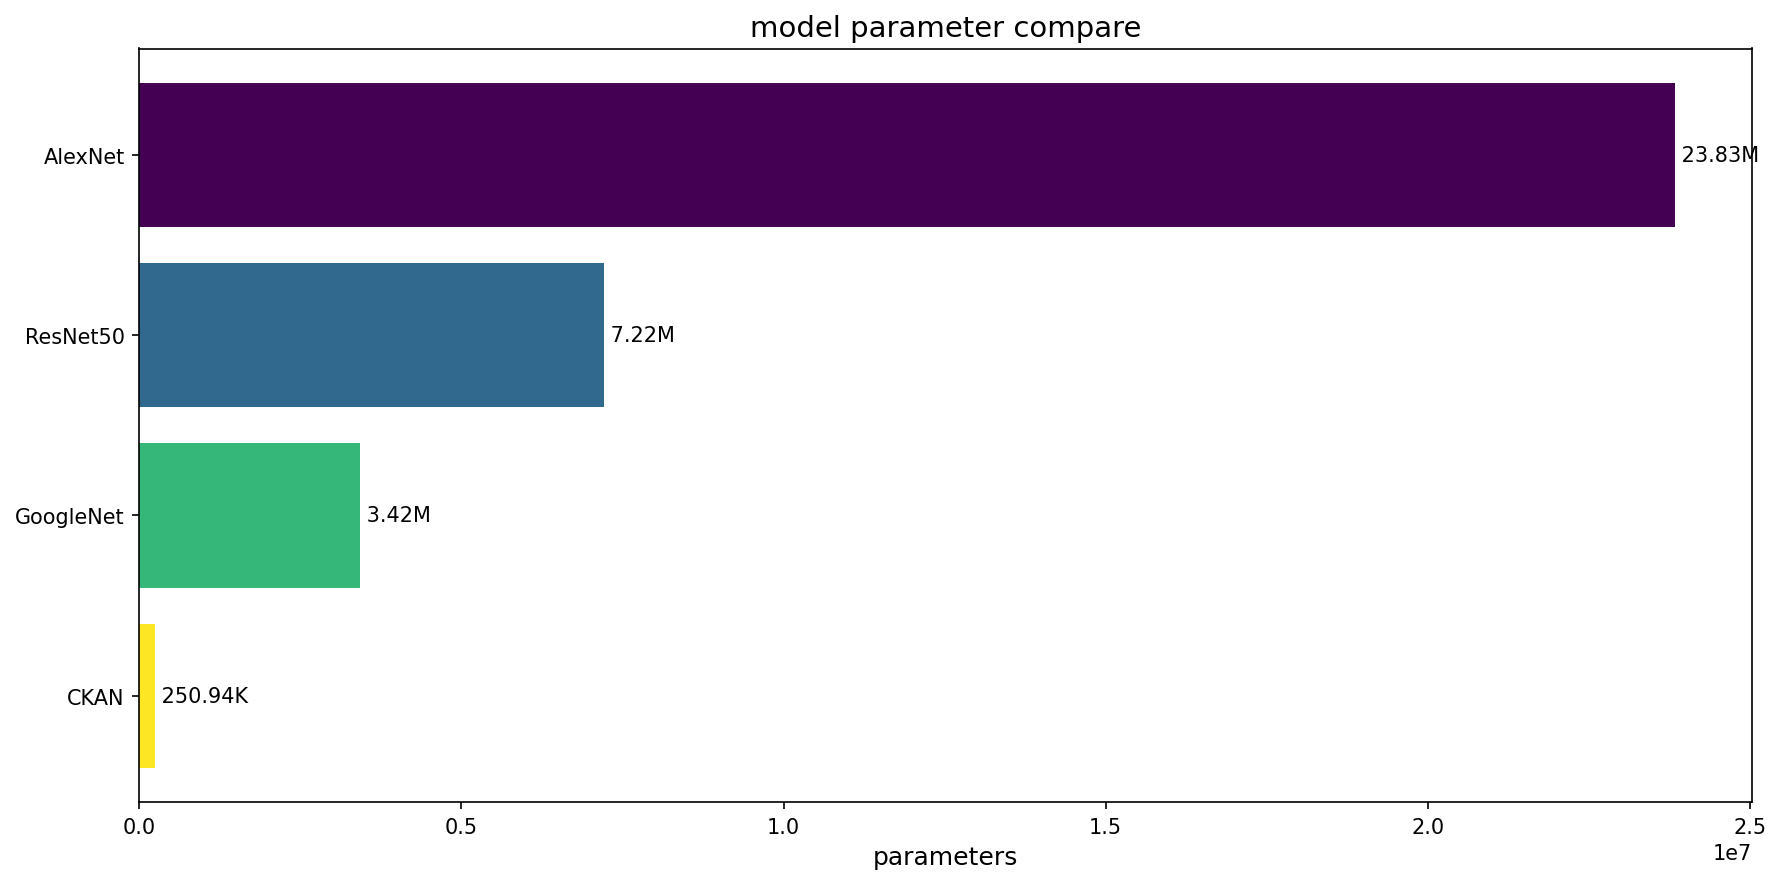

In [41]:
from IPython.display import Image, display

# 传入图片路径
img = Image("model_parameters_comparison.png")
display(img)

# 性能对比

In [39]:
results_df = pd.DataFrame({
        '模型': list(kernal_evals.keys()),
        '参数量': [kernal_evals[name]['total_params'] for name in kernal_evals.keys()],
        '测试准确率(%)': [kernal_evals[name]['test_accuracy'] * 100 for name in kernal_evals.keys()],
        '测试F1分数(%)': [kernal_evals[name]['test_f1'] * 100 for name in kernal_evals.keys()],
        '测试AUC(%)': [kernal_evals[name]['test_auc'] * 100 for name in kernal_evals.keys()]
    }).sort_values('测试准确率(%)', ascending=False)

results_df['参数量显示'] = results_df['参数量'].apply(
        lambda x: f"{x / 1e6:.2f}M" if x > 1e6 else (f"{x / 1e3:.2f}K" if x > 1e3 else str(x))
    )

In [40]:
print(results_df[['模型', '参数量显示', '测试准确率(%)', '测试F1分数(%)', '测试AUC(%)']].to_string(index=False))

       模型   参数量显示  测试准确率(%)  测试F1分数(%)  测试AUC(%)
  AlexNet  23.83M 99.880929  99.872003 99.989738
 ResNet50   7.22M 99.841238  99.829395 99.989305
GoogleNet   3.42M 99.769796  99.752729 99.991096
     CKAN 250.94K 99.730105  99.709799 99.988723
